# Concrete Compressive Strength Prediction

Predicting the compressive strength (MPa) of concrete from its mix design and age, using machine learning guided by concrete technology principles.

## Data
UCI *Concrete Compressive Strength* dataset (I-Cheng Yeh): 1,030 laboratory tests, 8 inputs and 1 target.

| Column | Meaning | Unit |
|---|---|---|
| `cement` | Portland cement | kg/m³ |
| `slag` | Blast furnace slag | kg/m³ |
| `fly_ash` | Fly ash | kg/m³ |
| `water` | Water | kg/m³ |
| `superplasticizer` | Superplasticizer | kg/m³ |
| `coarse_agg` | Coarse aggregate | kg/m³ |
| `fine_agg` | Fine aggregate | kg/m³ |
| `age` | Age at test | days |
| `strength` | **Target:** compressive strength | MPa |

## Approach
1. Load and clean the data
2. Exploratory data analysis (EDA), guided by concrete technology principles
3. A leakage-safe validation scheme that splits by **mix recipe**, not by row
4. A ladder of baseline models, from a simple average to gradient boosting, with and without engineering-based features
5. A single final evaluation on a held-out test set

## Key results
- Best model: **Gradient Boosting + domain features** (water–cement ratio, log of age)
- Cross-validated RMSE: **6.11 MPa**; held-out test RMSE: **5.20 MPa**, R² = **0.896**
- Engineering-based features cut the linear model's error by about **30%**

## 1. Setup and Data Loading

The dataset is read from the repository's `data/` folder (`Concrete_Data.xls`, from the UCI Machine Learning Repository).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_excel("../data/Concrete_Data.xls")
print(df.shape)

(1030, 9)


In [3]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
df.columns = ["cement","slag", "fly_ash","water","superplasticizer" ,"coarse_agg" ,"fine_agg","age","strength"]

print(df.isna().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicated rows")

0 missing values
25 duplicated rows


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)

(1005, 9)


**Data check:** no missing values and 25 exact duplicate rows (repeated lab records). The duplicates are removed, leaving **1,005 tests**. Column names are shortened for readability.

## 2. Exploratory Data Analysis (EDA)

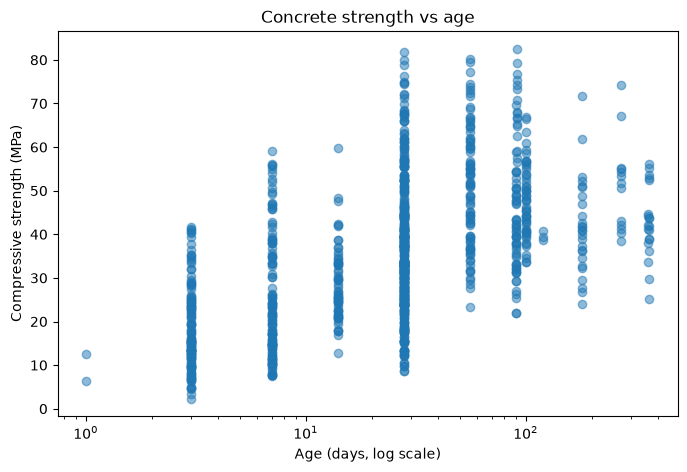

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["strength"], alpha=0.5)
plt.xscale("log")
plt.xlabel("Age (days, log scale)")
plt.ylabel("Compressive strength (MPa)")
plt.title("Concrete strength vs age")
plt.show()

**Observation: Strength vs Age**

- Most tests are concentrated around 28 days (the thick band in the middle), since 28-day strength is the standard design strength in concrete practice. There are fewer tests at very early ages (1–3 days) and very late ages (180–365 days).

- Strength rises quickly in the first 28 days and then gains more slowly, consistent with cement hydration slowing over time.

- At any single age, strength varies widely, so age alone can't predict strength. The mix design must explain the rest.

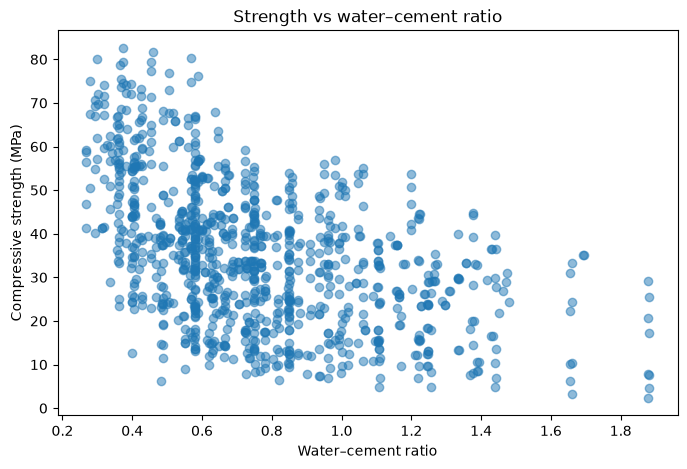

In [7]:
df["wc_ratio"] = df["water"] / df["cement"]

plt.figure(figsize=(8, 5))
plt.scatter(df["wc_ratio"], df["strength"], alpha=0.5)
plt.xlabel("Water–cement ratio")
plt.ylabel("Compressive strength (MPa)")
plt.title("Strength vs water–cement ratio")
plt.show()

In [8]:
print("Water alone:   ", round(df["strength"].corr(df["water"], method="spearman"), 2))
print("W/C ratio:     ", round(df["strength"].corr(df["wc_ratio"], method="spearman"), 2))

Water alone:    -0.28
W/C ratio:      -0.5


**Observation: Water–Cement Ratio**

- Created a new feature, `wc_ratio` = water / cement.

- In line with Abrams' law, strength decreases as the w/c ratio increases.

- Spearman correlation with strength: water alone = −0.28, w/c ratio = −0.50. The ratio is roughly twice as strongly related to strength as water alone, showing that an engineering-based feature is more informative than the raw column.

In [9]:
((df == 0).mean() * 100).round(1)

cement               0.0
slag                46.3
fly_ash             53.8
water                0.0
superplasticizer    37.6
coarse_agg           0.0
fine_agg             0.0
age                  0.0
strength             0.0
wc_ratio             0.0
dtype: float64

**Slag (46%), fly ash (54%) and superplasticizer (38%) contain zeros**, meaning the material wasn't used in that mix. These are real values, so they're kept.

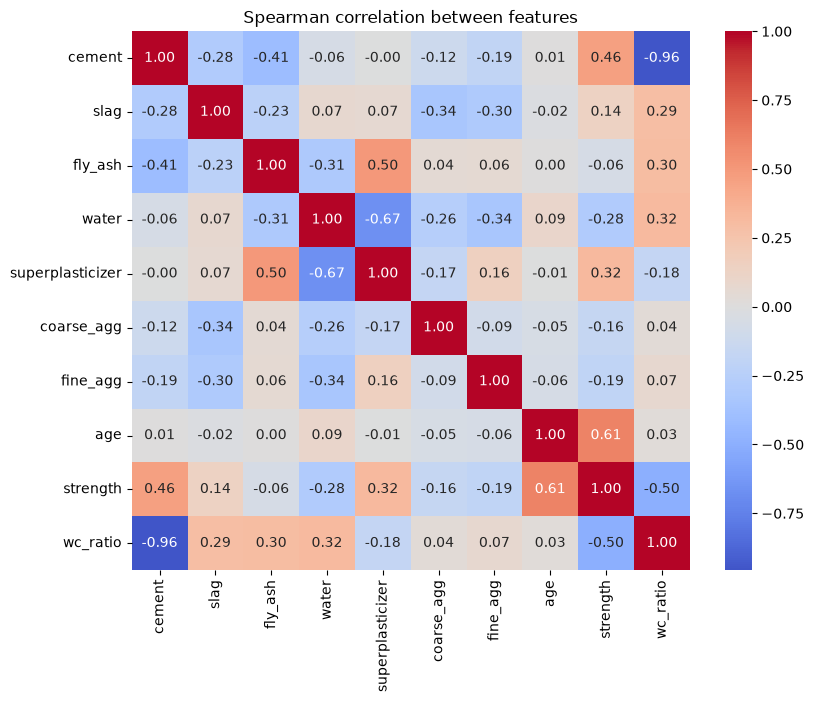

In [10]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation between features")
plt.show()

**Observation: Correlations with Strength**

- Age has the strongest positive link with strength (0.61), followed by cement (0.46).

- The w/c ratio has the strongest negative link (−0.5), consistent with Abrams' law.

- Strength depends on several factors together (age, cement content, w/c ratio), which suggests a model combining them will predict better than any single feature.

## 3. Validation Scheme

In [11]:
mix_cols = ["cement", "slag", "fly_ash", "water",
            "superplasticizer", "coarse_agg", "fine_agg"]

df["mix_id"] = df.groupby(mix_cols).ngroup()
print(df["mix_id"].nunique(), "unique mixes")

428 unique mixes


The **1,005 tests** come from **428 unique mix recipes**, many tested at several ages. To avoid data leakage, the data will be split by mix rather than by row.

In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["mix_id"]))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

print("Train:", train_df.shape, "| Test:", test_df.shape)
print("Shared mixes:", len(set(train_df["mix_id"]) & set(test_df["mix_id"])))

Train: (810, 11) | Test: (195, 11)
Shared mixes: 0


Split the data by mix into **train (810 rows)** and **test (195 rows)**, with no mix appearing in both. The test set is kept aside until final evaluation.

## 4. Baseline Modelling

In [13]:
features = ["cement", "slag", "fly_ash", "water",
            "superplasticizer", "coarse_agg", "fine_agg", "age"]

X_train = train_df[features]
y_train = train_df["strength"]
groups_train = train_df["mix_id"]

X_test = test_df[features]
y_test = test_df["strength"]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(810, 8) (810,) (195, 8) (195,)


In [14]:
cv = GroupKFold(n_splits=5)

dummy = DummyRegressor(strategy="mean")

scores = cross_val_score(dummy, X_train, y_train, groups=groups_train,
                         cv=cv, scoring="neg_root_mean_squared_error")

rmse = -scores
print("RMSE per fold:", rmse.round(2))
print("Mean RMSE:", rmse.mean().round(2), "MPa")

RMSE per fold: [16.87 15.55 15.83 17.9  15.52]
Mean RMSE: 16.34 MPa


Baseline (Dummy, predicts mean strength): **CV RMSE = 16.34 MPa**. Any useful model must beat this.

In [15]:
linear = LinearRegression()

scores = cross_val_score(linear, X_train, y_train, groups=groups_train,
                         cv=cv, scoring="neg_root_mean_squared_error")

rmse = -scores
print("RMSE per fold:", rmse.round(2))
print("Mean RMSE:", rmse.mean().round(2), "MPa")

RMSE per fold: [11.09 10.26 10.64 11.47 10.03]
Mean RMSE: 10.7 MPa


Linear Regression (8 raw features): **CV RMSE = 10.70 MPa**, a 35% improvement over the baseline.

In [16]:
train_df = train_df.copy()
test_df = test_df.copy()
train_df["log_age"] = np.log(train_df["age"])
test_df["log_age"] = np.log(test_df["age"])

features_fe = ["cement", "slag", "fly_ash", "water", "superplasticizer",
               "coarse_agg", "fine_agg", "wc_ratio", "log_age"]

X_train_fe = train_df[features_fe]
X_test_fe = test_df[features_fe]

scores = cross_val_score(LinearRegression(), X_train_fe, y_train, groups=groups_train,
                         cv=cv, scoring="neg_root_mean_squared_error")

rmse = -scores
print("RMSE per fold:", rmse.round(2))
print("Mean RMSE:", rmse.mean().round(2), "MPa")

RMSE per fold: [8.3  7.16 7.17 7.79 6.88]
Mean RMSE: 7.46 MPa


Linear Regression + domain features (wc_ratio, log_age): **CV RMSE = 7.46 MPa**, a 30% improvement over raw features, showing that engineering knowledge adds real predictive value.

In [17]:
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

scores = cross_val_score(rf, X_train, y_train, groups=groups_train,
                         cv=cv, scoring="neg_root_mean_squared_error")

rmse = -scores
print("RMSE per fold:", rmse.round(2))
print("Mean RMSE:", rmse.mean().round(2), "MPa")

RMSE per fold: [7.57 5.35 6.22 6.76 6.74]
Mean RMSE: 6.53 MPa


Random Forest (8 raw features): **CV RMSE = 6.53 MPa**. Non-linear trees capture the curved age effect and material interactions without manual feature engineering.

In [18]:
gb = HistGradientBoostingRegressor(random_state=42)

scores = cross_val_score(gb, X_train, y_train, groups=groups_train,
                         cv=cv, scoring="neg_root_mean_squared_error")

rmse = -scores
print("RMSE per fold:", rmse.round(2))
print("Mean RMSE:", rmse.mean().round(2), "MPa")

RMSE per fold: [7.19 5.18 5.8  6.85 6.56]
Mean RMSE: 6.32 MPa


Gradient Boosting (8 raw features, default settings): **CV RMSE = 6.32 MPa**, the best baseline so far.

In [19]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_fe, y_train, groups=groups_train,
                             cv=cv, scoring="neg_root_mean_squared_error")
    print(name, "+ domain features: Mean RMSE =", (-scores).mean().round(2), "MPa")

Random Forest + domain features: Mean RMSE = 6.28 MPa
Gradient Boosting + domain features: Mean RMSE = 6.11 MPa


With domain features, Random Forest improved to 6.28 MPa and **Gradient Boosting to 6.11 MPa**. Gains are smaller than for Linear Regression because trees can learn non-linear patterns directly, but the w/c ratio still helps. Best model: Gradient Boosting + domain features.

## 5. Final Test Evaluation

The best model is trained on all 810 training rows and evaluated **once** on the 195 held-out test rows, from mixes it has never seen.

In [20]:
best_model = HistGradientBoostingRegressor(random_state=42)
best_model.fit(X_train_fe, y_train)

test_preds = best_model.predict(X_test_fe)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

print("Test RMSE:", round(test_rmse, 2), "MPa")
print("Test R²:  ", round(test_r2, 3))

Test RMSE: 5.2 MPa
Test R²:   0.896


Final test (Gradient Boosting + domain features, trained on all training data): **RMSE = 5.20 MPa, R² = 0.896.** The test score falls within the range of CV fold scores, confirming the mix-based validation gave a trustworthy estimate.

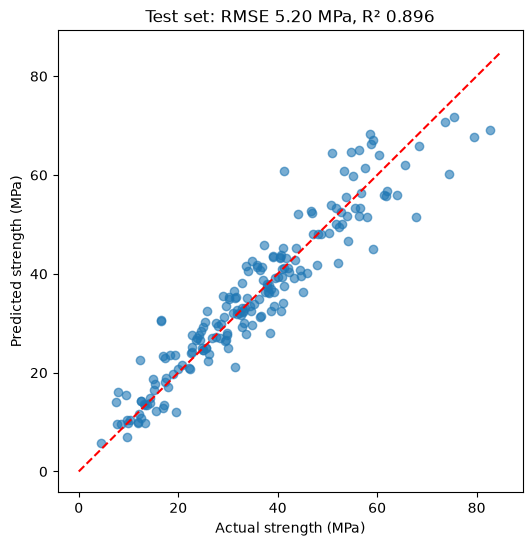

In [21]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds, alpha=0.6)
plt.plot([0, 85], [0, 85], color="red", linestyle="--")
plt.xlabel("Actual strength (MPa)")
plt.ylabel("Predicted strength (MPa)")
plt.title(f"Test set: RMSE {test_rmse:.2f} MPa, R² {test_r2:.3f}")
plt.show()

Predictions lie close to the ideal line across the strength range, showing good agreement between predicted and actual strength. At higher strengths (above about 60 MPa), the points are more spread out around the line, indicating larger errors for very strong mixes, likely because there are fewer high-strength samples in the data.

## 6. Save the Model

The trained model is saved with `joblib` so it can be reused (for example, in an app) without retraining. It expects the 9 features in `features_fe`, in the same order.

In [22]:
joblib.dump(best_model, "../models/concrete_gb_model.joblib")
print("Model saved")

Model saved


## 7. Summary

| Model | Features | CV RMSE (MPa) |
|---|---|---|
| Dummy (predicts mean) | – | 16.34 |
| Linear Regression | raw | 10.70 |
| Linear Regression | raw + domain | 7.46 |
| Random Forest | raw | 6.53 |
| Random Forest | raw + domain | 6.28 |
| Gradient Boosting | raw | 6.32 |
| **Gradient Boosting** | **raw + domain** | **6.11** |

**Final test:** RMSE = 5.20 MPa, R² = 0.896.

**Key takeaways**
- Splitting by mix recipe prevents data leakage, since the 1,005 tests come from only 428 unique mixes.
- Engineering knowledge adds real value: the water–cement ratio and log of age reduced the linear model's error by about 30%, and still improved the tree models.
- Gradient boosting performed best, with errors largest for high-strength mixes, which are less common in the data.

## 1: Heading: Additional EDA, grouped comparisons

Grouping the data into strength classes, curing ages and additive use, to compare categories rather than only individual points.

##  Cell 2: Groups creation


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eda = df.copy()

# Strength classes (MPa)
eda["strength_class"] = pd.cut(
    eda["strength"],
    bins=[0, 20, 40, np.inf],
    labels=["Low (<20 MPa)", "Medium (20–40 MPa)", "High (>40 MPa)"],
)

# Curing age groups (days)
eda["age_group"] = pd.cut(
    eda["age"],
    bins=[0, 7, 28, 91, np.inf],
    labels=["≤7 days", "14–28 days", "56–91 days", ">91 days"],
)

print(eda["strength_class"].value_counts().sort_index())
print()
print(eda["age_group"].value_counts().sort_index())

strength_class
Low (<20 MPa)         196
Medium (20–40 MPa)    449
High (>40 MPa)        360
Name: count, dtype: int64

age_group
≤7 days       253
14–28 days    481
56–91 days    157
>91 days      114
Name: count, dtype: int64


## 3: Strength distribution

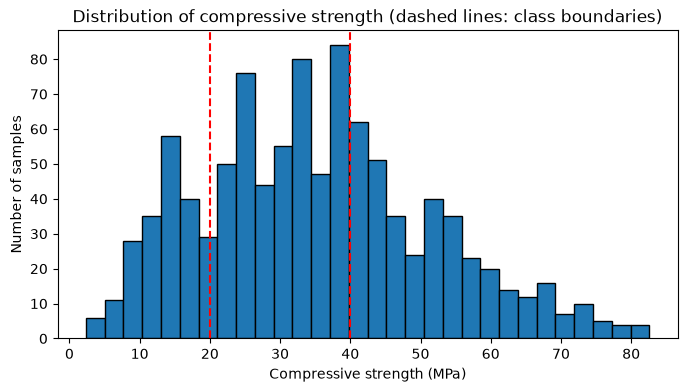

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(eda["strength"], bins= 30, edgecolor="black")
for x in [20, 40]:
    ax.axvline(x, linestyle="--", color="red")
ax.set_xlabel("Compressive strength (MPa)")
ax.set_ylabel("Number of samples")
ax.set_title("Distribution of compressive strength (dashed lines: class boundaries)")
plt.show()

Most samples lie between about 20 and 45 MPa, with a long tail of high-strength mixes up to about 80 MPa.

## 4: Strength by age, and w/c ratio by strength class

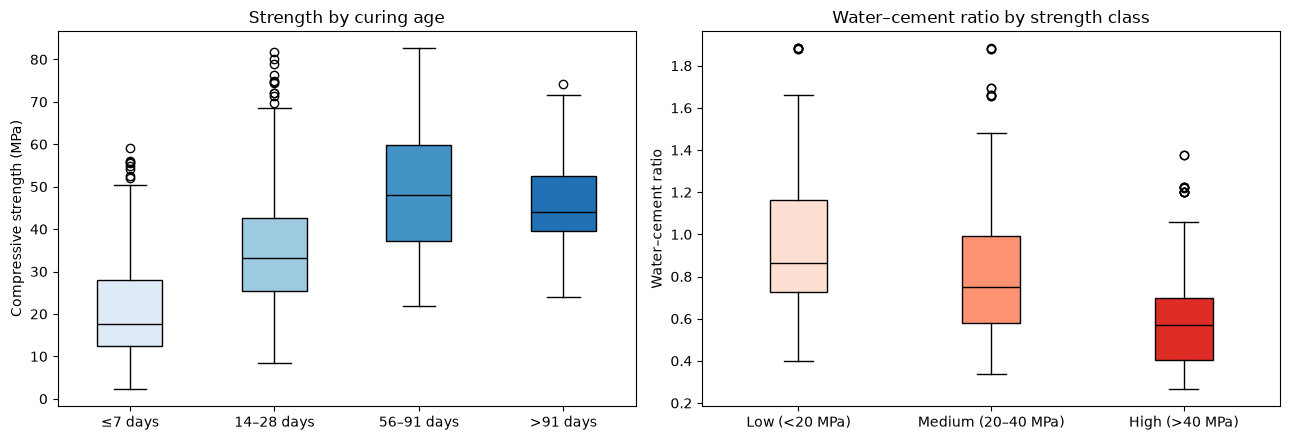

In [29]:
def grouped_boxplot(ax, data, value_col, group_col, order, title, ylabel, colors=None):
    values = [data.loc[data[group_col] == g, value_col] for g in order]
    box = ax.boxplot(values, patch_artist=True)
    if colors:
        for patch, c in zip(box["boxes"], colors):
            patch.set_facecolor(c)
    for median in box["medians"]:
        median.set_color("black")
    ax.set_xticks(range(1, len(order) + 1), order)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

age_colors = ["#deebf7", "#9ecae1", "#4292c6", "#2171b5"]   # light → dark blue
class_colors = ["#fee0d2", "#fc9272", "#de2d26"]            # light → dark red

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
grouped_boxplot(axes[0], eda, "strength", "age_group",
                list(eda["age_group"].cat.categories),
                "Strength by curing age", "Compressive strength (MPa)",
                colors=age_colors)
grouped_boxplot(axes[1], eda, "wc_ratio", "strength_class",
                list(eda["strength_class"].cat.categories),
                "Water–cement ratio by strength class", "Water–cement ratio",
                colors=class_colors)
plt.tight_layout()
plt.show()

Strength rises clearly with curing age up to 56–91 days. The >91 days group is slightly lower, not because concrete loses strength, but because different mixes were tested at different ages.

The water–cement ratio falls steadily from low- to high-strength mixes, as Abrams' law predicts. However, the groups overlap, so w/c ratio alone cannot determine strength. This motivates a model that uses all mix components together.

## 5: With vs without additives

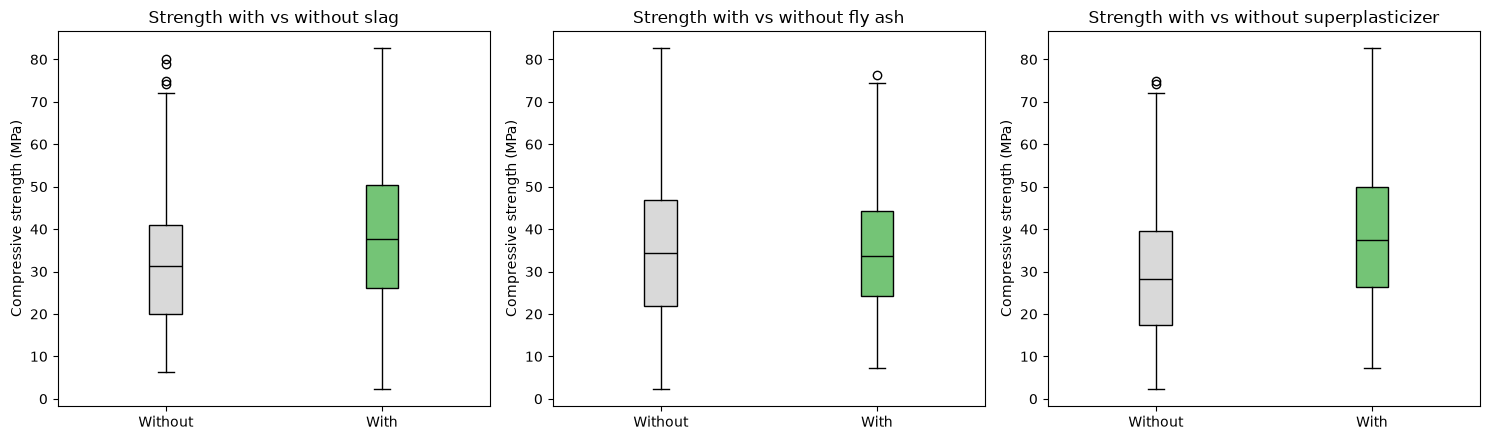

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, name in zip(axes,
                         ["slag", "fly_ash", "superplasticizer"],
                         ["slag", "fly ash", "superplasticizer"]):
    eda[col + "_used"] = np.where(eda[col] > 0, "With", "Without")
    grouped_boxplot(ax, eda, "strength", col + "_used", ["Without", "With"],
                    f"Strength with vs without {name}", "Compressive strength (MPa)",
                    colors=["#d9d9d9", "#74c476"])   # grey = without, green = with
plt.tight_layout()
plt.show()

Mixes with slag or superplasticizer have higher median strength, while fly ash makes little difference, consistent with its slower strength gain. These are associations only: other mix properties also differ between the groups (for example, mixes with superplasticizer tend to have lower w/c ratios).

## 6. Correlation heatmap

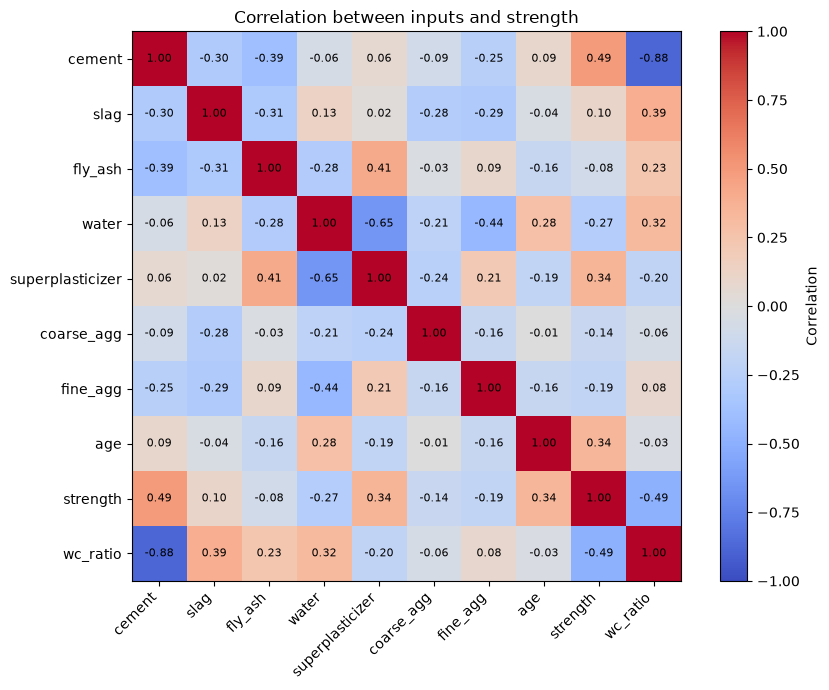

In [31]:
corr = df.select_dtypes("number").drop(columns=["mix_id"], errors="ignore").corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation between inputs and strength")
plt.tight_layout()
plt.show()

Strength correlates most with cement content, w/c ratio (negatively), superplasticizer and age. Correlation only captures straight-line relationships, so it understates age, whose effect on strength is strong but non-linear (hence the log-of-age feature).

## 1. Engineering baseline: Abrams' law
Abrams' law (1918) relates strength to the water–cement ratio: strength = A / B^(w/c). Taking logs gives a straight line, log(strength) = a + b·(w/c), which can be fitted with linear regression. Two versions are compared with the final model on the same test set: w/c only, and w/c plus log of curing age.

## 2: Fit and compare

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def abrams_features(d, with_age=False):
    feats = pd.DataFrame({"wc": d["water"] / d["cement"]})
    if with_age:
        feats["log_age"] = np.log(d["age"])
    return feats

print("Same test set as final model:", len(test_df) == len(y_test))

abrams_results = {}
for name, with_age in [("Abrams (w/c only)", False), ("Abrams + log(age)", True)]:
    abrams_model = LinearRegression()
    abrams_model.fit(abrams_features(train_df, with_age), np.log(train_df["strength"]))
    abrams_pred = np.exp(abrams_model.predict(abrams_features(test_df, with_age)))
    abrams_results[name] = (
        np.sqrt(mean_squared_error(test_df["strength"], abrams_pred)),
        r2_score(test_df["strength"], abrams_pred),
    )

abrams_results["Gradient boosting (final model)"] = (
    np.sqrt(mean_squared_error(y_test, test_preds)),
    r2_score(y_test, test_preds),
)

comparison = pd.DataFrame(abrams_results, index=["Test RMSE (MPa)", "Test R²"]).T.round(3)
comparison

Same test set as final model: True


,Test RMSE (MPa),Test R²
Abrams (w/c only),13.387,0.313
Abrams + log(age),11.594,0.485
Gradient boosting (final model),5.200,0.896


**Result:** The Abrams formula using w/c ratio alone gives a test RMSE of 13.39 MPa (R² = 0.313). Adding log of curing age improves this to 11.59 MPa (R² = 0.485). The gradient boosting model reaches 5.20 MPa (R² = 0.896).

Abrams' law captures the main trend, since strength falls as the w/c ratio rises. However, it ignores the other mix components (slag, fly ash, superplasticizer, aggregates) and how they interact. The gradient boosting model uses all of them together, which cuts the error by about 55% compared with the best Abrams version. The formula is still a useful, interpretable rule of thumb, but the ML model gives much more accurate predictions for these mixes.